In [19]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — Imports
# ═══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Imports done")

✅ Imports done


In [20]:
# ═══════════════════════════════════════════════════════════
# CELL 2 — Load Data
# ═══════════════════════════════════════════════════════════
train_df = pd.read_csv("../data/raw/train.csv")
val_df   = pd.read_csv("../data/raw/val.csv")
test_df  = pd.read_csv("../data/raw/test.csv")

# ✅ Column check only — no analysis on val/test
print("── Shapes ──────────────────────────────")
print(f"  Train : {train_df.shape}")
print(f"  Val   : {val_df.shape}")
print(f"  Test  : {test_df.shape}")

assert list(train_df.columns) == list(val_df.columns) == list(test_df.columns), \
    "❌ Column mismatch!"
print("\n  ✅ Columns match across all sets")

# ✅ Remove val and test immediately — EDA on Train only
del val_df, test_df
print("  ✅ Val and Test removed — all EDA below is Train only")

print("\n── First look at Train ─────────────────")
train_df.head()

── Shapes ──────────────────────────────
  Train : (170884, 31)
  Val   : (56960, 31)
  Test  : (56960, 31)

  ✅ Columns match across all sets
  ✅ Val and Test removed — all EDA below is Train only

── First look at Train ─────────────────


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,119191.0,2.052427,-0.133236,-1.740621,0.277935,0.337999,-0.826933,0.334629,-0.227039,0.267655,...,-0.006518,0.121300,0.037733,-0.356498,0.147822,0.569149,-0.103929,-0.091958,8.73,0
1,71750.0,1.220356,-0.159191,-0.444349,-0.094437,0.104457,-0.345790,0.170867,-0.094996,0.187572,...,-0.088775,-0.364654,-0.140851,-0.707308,0.415661,1.087767,-0.102532,-0.008335,59.95,0
2,151977.0,0.892824,-1.440698,-0.637940,3.912871,0.099291,2.433288,-0.308891,0.603227,-0.113826,...,0.484969,0.487304,-0.122694,-0.598803,-0.594563,0.062841,-0.033426,0.038254,460.65,0
3,55709.0,-3.146021,2.247634,0.901397,0.146162,-2.109360,-0.148312,-1.533191,2.073663,0.499394,...,0.050567,-0.037019,0.107000,0.392857,0.303597,0.379544,-0.148990,0.074965,4.78,0
4,66654.0,1.194996,-0.007495,0.301285,0.750199,-0.297494,-0.405836,0.060410,-0.150482,0.400860,...,-0.234931,-0.545566,-0.089418,-0.064036,0.527305,0.294221,-0.025980,0.015637,44.31,0


In [21]:
# ═══════════════════════════════════════════════════════════
# CELL 3 — Basic Stats
# ═══════════════════════════════════════════════════════════
print("── Data Types ──────────────────────────")
print(train_df.dtypes)

print("\n── Missing Values (Train) ──────────────")
missing = train_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  ✅ No missing values")

print("\n── Statistical Summary ─────────────────")
train_df.describe().T

── Data Types ──────────────────────────
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

── Missing Values (Train) ──────────────
  ✅ No missing values

── Statistical Summary ─────────────────


,count,mean,std,min,25%,50%,75%,max
Time,170884.0,94966.107886,47464.723773,0.000000,54348.000000,84923.500000,139404.000000,172792.000000
V1,170884.0,-0.001070,1.958944,-46.855047,-0.922071,0.016603,1.316250,2.451888
V2,170884.0,-0.000904,1.650481,-63.344698,-0.599127,0.065839,0.802518,22.057729
V3,170884.0,-0.002722,1.521820,-48.325589,-0.896376,0.177007,1.028302,4.226108
V4,170884.0,-0.002603,1.416490,-5.683171,-0.848978,-0.020895,0.738812,16.875344
V5,170884.0,0.000151,1.394123,-113.743307,-0.691840,-0.054185,0.612154,34.099309
V6,170884.0,0.000779,1.338331,-23.496714,-0.768986,-0.274228,0.400359,73.301626
V7,170884.0,-0.000811,1.260122,-43.557242,-0.554440,0.040417,0.569221,120.589494
V8,170884.0,-0.002327,1.208709,-73.216718,-0.209596,0.021461,0.326026,18.282168
V9,170884.0,-0.000622,1.098393,-13.434066,-0.642036,-0.051777,0.595095,10.392889


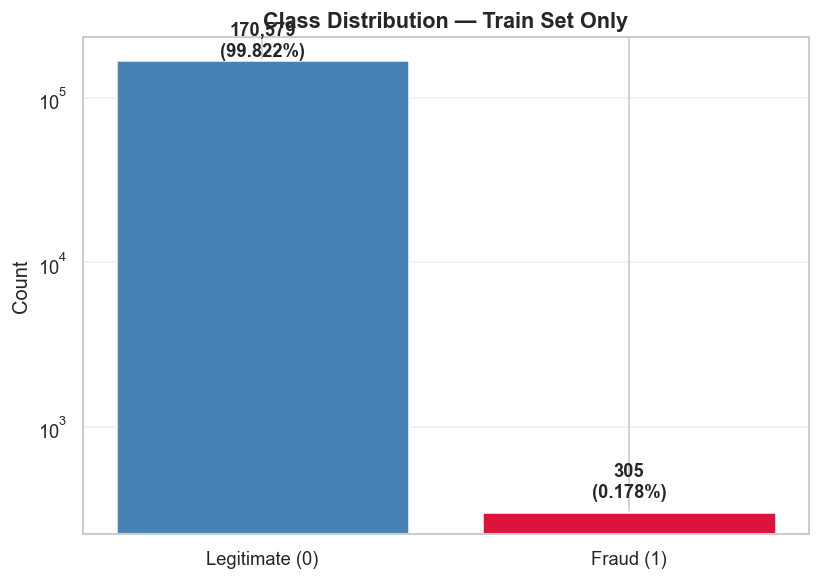

In [22]:
# ═══════════════════════════════════════════════════════════
# CELL 4 — Target Distribution (Train ONLY)
# ═══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 5))

counts = train_df["Class"].value_counts()
pct    = train_df["Class"].value_counts(normalize=True) * 100

bars = ax.bar(["Legitimate (0)", "Fraud (1)"],
              counts.values,
              color=["steelblue", "crimson"],
              edgecolor="white", linewidth=1.5)

for bar, count, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            f"{count:,}\n({p:.3f}%)",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_title("Class Distribution — Train Set Only",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/class_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# ═══════════════════════════════════════════════════════════
# CELL 5 — Imbalance Ratio 
# ═══════════════════════════════════════════════════════════
fraud_count     = train_df["Class"].sum()
legit_count     = (train_df["Class"] == 0).sum()
imbalance_ratio = legit_count / fraud_count

print(f"  Fraud transactions : {fraud_count:,}")
print(f"  Legitimate transactions : {legit_count:,}")
print(f"  Imbalance ratio    : {imbalance_ratio:.1f}:1")
print(f"\n  ⚠️  For every 1 fraud → {imbalance_ratio:.0f} legitimate transactions")
print(f"  XGBoost scale_pos_weight = {imbalance_ratio:.2f}")

  Fraud transactions : 305
  Legitimate transactions : 170,579
  Imbalance ratio    : 559.3:1

  ⚠️  For every 1 fraud → 559 legitimate transactions
  XGBoost scale_pos_weight = 559.28


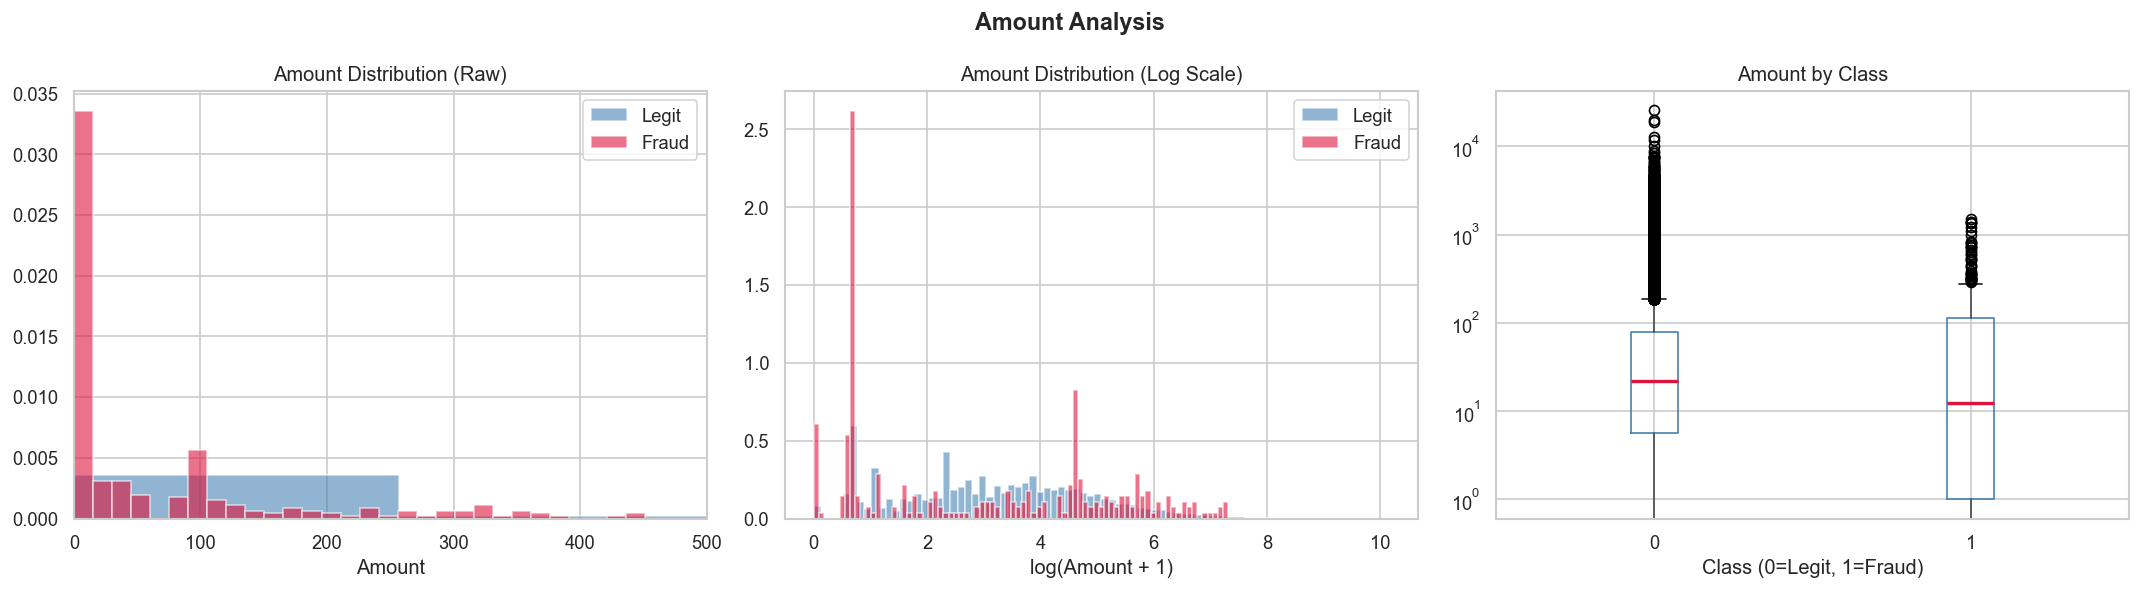

── Amount Statistics by Class ───────────────
          count    mean     std  min   25%    50%    75%       max
Class                                                             
0      170579.0   88.44  256.74  0.0  5.68  22.04   77.5  25691.16
1         305.0  126.75  253.34  0.0  1.00  12.31  111.7   1504.93


In [24]:
# ═══════════════════════════════════════════════════════════
# CELL 6 — Amount Analysis
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fraud = train_df[train_df["Class"] == 1]["Amount"]
legit = train_df[train_df["Class"] == 0]["Amount"]

# Plot 1: Distribution of Amount (raw)
axes[0].hist(legit,  bins=100, alpha=0.6, color="steelblue", label="Legit",  density=True)
axes[0].hist(fraud,  bins=100, alpha=0.6, color="crimson",   label="Fraud",  density=True)
axes[0].set_title("Amount Distribution (Raw)")
axes[0].set_xlabel("Amount")
axes[0].legend()
axes[0].set_xlim(0, 500)

# Plot 2: Distribution of Amount (log scale)
axes[1].hist(np.log1p(legit), bins=80, alpha=0.6, color="steelblue", label="Legit", density=True)
axes[1].hist(np.log1p(fraud), bins=80, alpha=0.6, color="crimson",   label="Fraud", density=True)
axes[1].set_title("Amount Distribution (Log Scale)")
axes[1].set_xlabel("log(Amount + 1)")
axes[1].legend()

# Plot 3: Boxplot Amount by Class
train_df.boxplot(column="Amount", by="Class", ax=axes[2],
                 boxprops=dict(color="steelblue"),
                 medianprops=dict(color="crimson", linewidth=2))
axes[2].set_title("Amount by Class")
axes[2].set_xlabel("Class (0=Legit, 1=Fraud)")
axes[2].set_yscale("log")

plt.suptitle("Amount Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/amount_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("── Amount Statistics by Class ───────────────")
print(train_df.groupby("Class")["Amount"].describe().round(2))

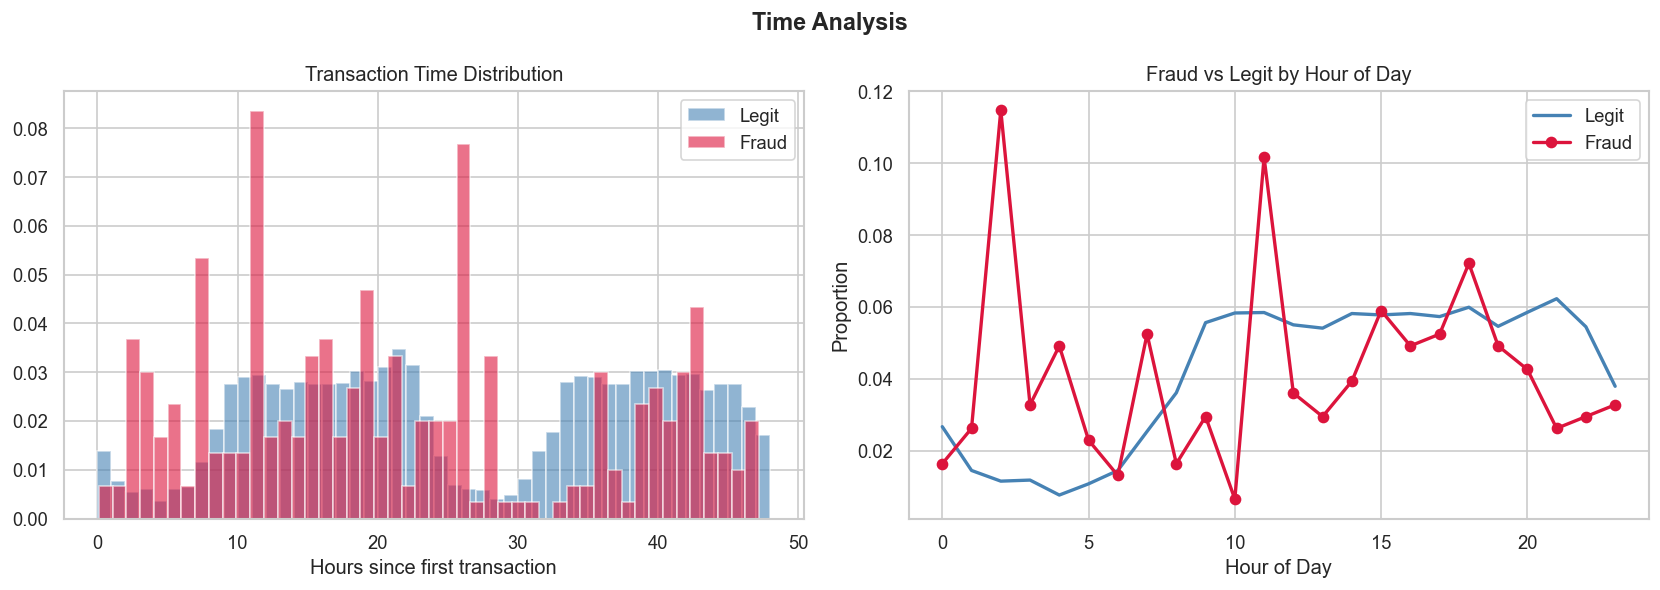

In [25]:
# ═══════════════════════════════════════════════════════════
# CELL 7 — Time Analysis
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_time = train_df[train_df["Class"] == 1]["Time"]
legit_time = train_df[train_df["Class"] == 0]["Time"]

# Plot 1: Time distribution
axes[0].hist(legit_time / 3600, bins=48, alpha=0.6,
             color="steelblue", label="Legit",  density=True)
axes[0].hist(fraud_time / 3600, bins=48, alpha=0.6,
             color="crimson",   label="Fraud",  density=True)
axes[0].set_title("Transaction Time Distribution")
axes[0].set_xlabel("Hours since first transaction")
axes[0].legend()

# Plot 2: Hour of day
train_df["hour_of_day"] = (train_df["Time"] // 3600) % 24

fraud_by_hour = train_df[train_df["Class"] == 1]["hour_of_day"].value_counts().sort_index()
legit_by_hour = train_df[train_df["Class"] == 0]["hour_of_day"].value_counts().sort_index()

axes[1].plot(legit_by_hour.index,
             legit_by_hour.values / legit_by_hour.sum(),
             color="steelblue", label="Legit",  linewidth=2)
axes[1].plot(fraud_by_hour.index,
             fraud_by_hour.values / fraud_by_hour.sum(),
             color="crimson",   label="Fraud",  linewidth=2, marker="o")
axes[1].set_title("Fraud vs Legit by Hour of Day")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Proportion")
axes[1].legend()

plt.suptitle("Time Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/time_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Drop the temp column
train_df.drop(columns=["hour_of_day"], inplace=True)

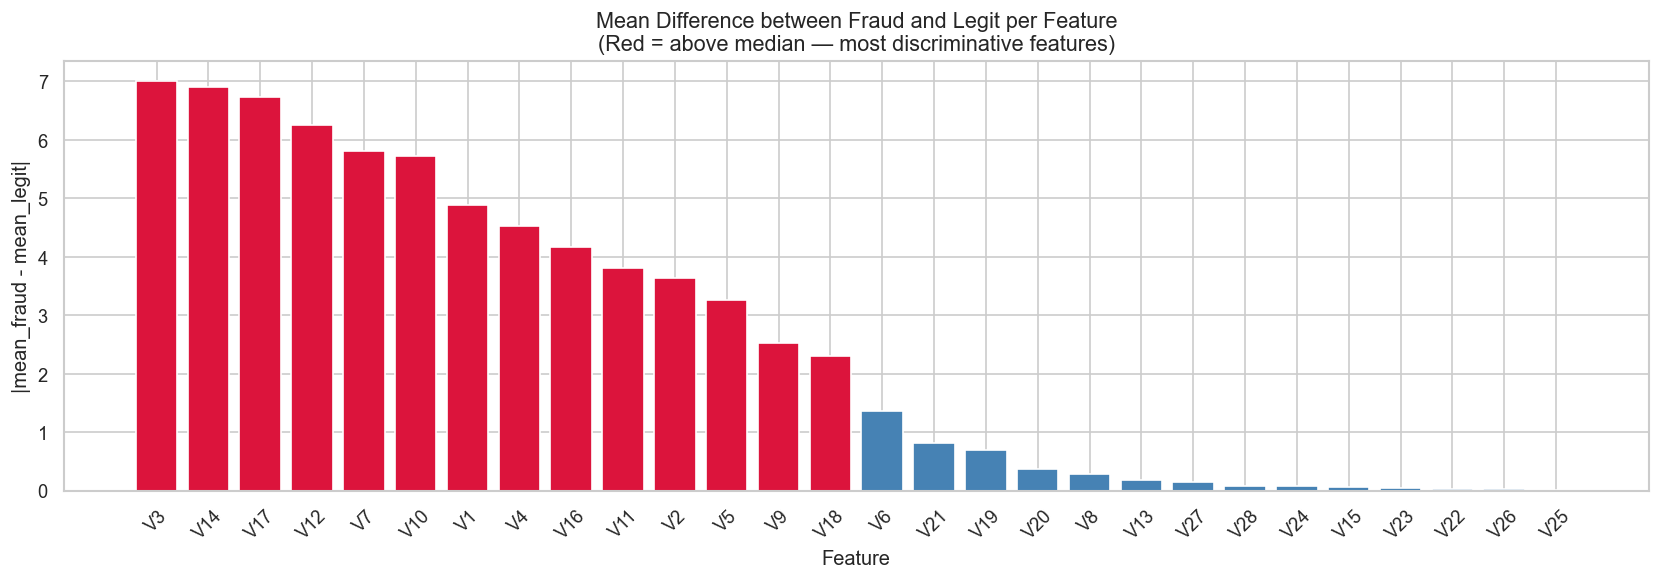

── Top 10 most discriminative features ──────
V3     7.0069
V14    6.9119
V17    6.7318
V12    6.2620
V7     5.8094
V10    5.7188
V1     4.8793
V4     4.5240
V16    4.1767
V11    3.8034
dtype: float64


In [26]:
# ═══════════════════════════════════════════════════════════
# CELL 8 — V Features: Which ones separate Fraud from Legit?
# ═══════════════════════════════════════════════════════════
v_features = [f"V{i}" for i in range(1, 29)]

fraud_df = train_df[train_df["Class"] == 1]
legit_df = train_df[train_df["Class"] == 0]

# Compute mean difference between fraud and legit per feature
mean_diff = {}
for col in v_features:
    mean_diff[col] = abs(fraud_df[col].mean() - legit_df[col].mean())

mean_diff_series = pd.Series(mean_diff).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["crimson" if v > mean_diff_series.median()
          else "steelblue" for v in mean_diff_series.values]
ax.bar(mean_diff_series.index, mean_diff_series.values, color=colors)
ax.set_title("Mean Difference between Fraud and Legit per Feature\n"
             "(Red = above median — most discriminative features)",
             fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("|mean_fraud - mean_legit|")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/feature_discriminability.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("── Top 10 most discriminative features ──────")
print(mean_diff_series.head(10).round(4))

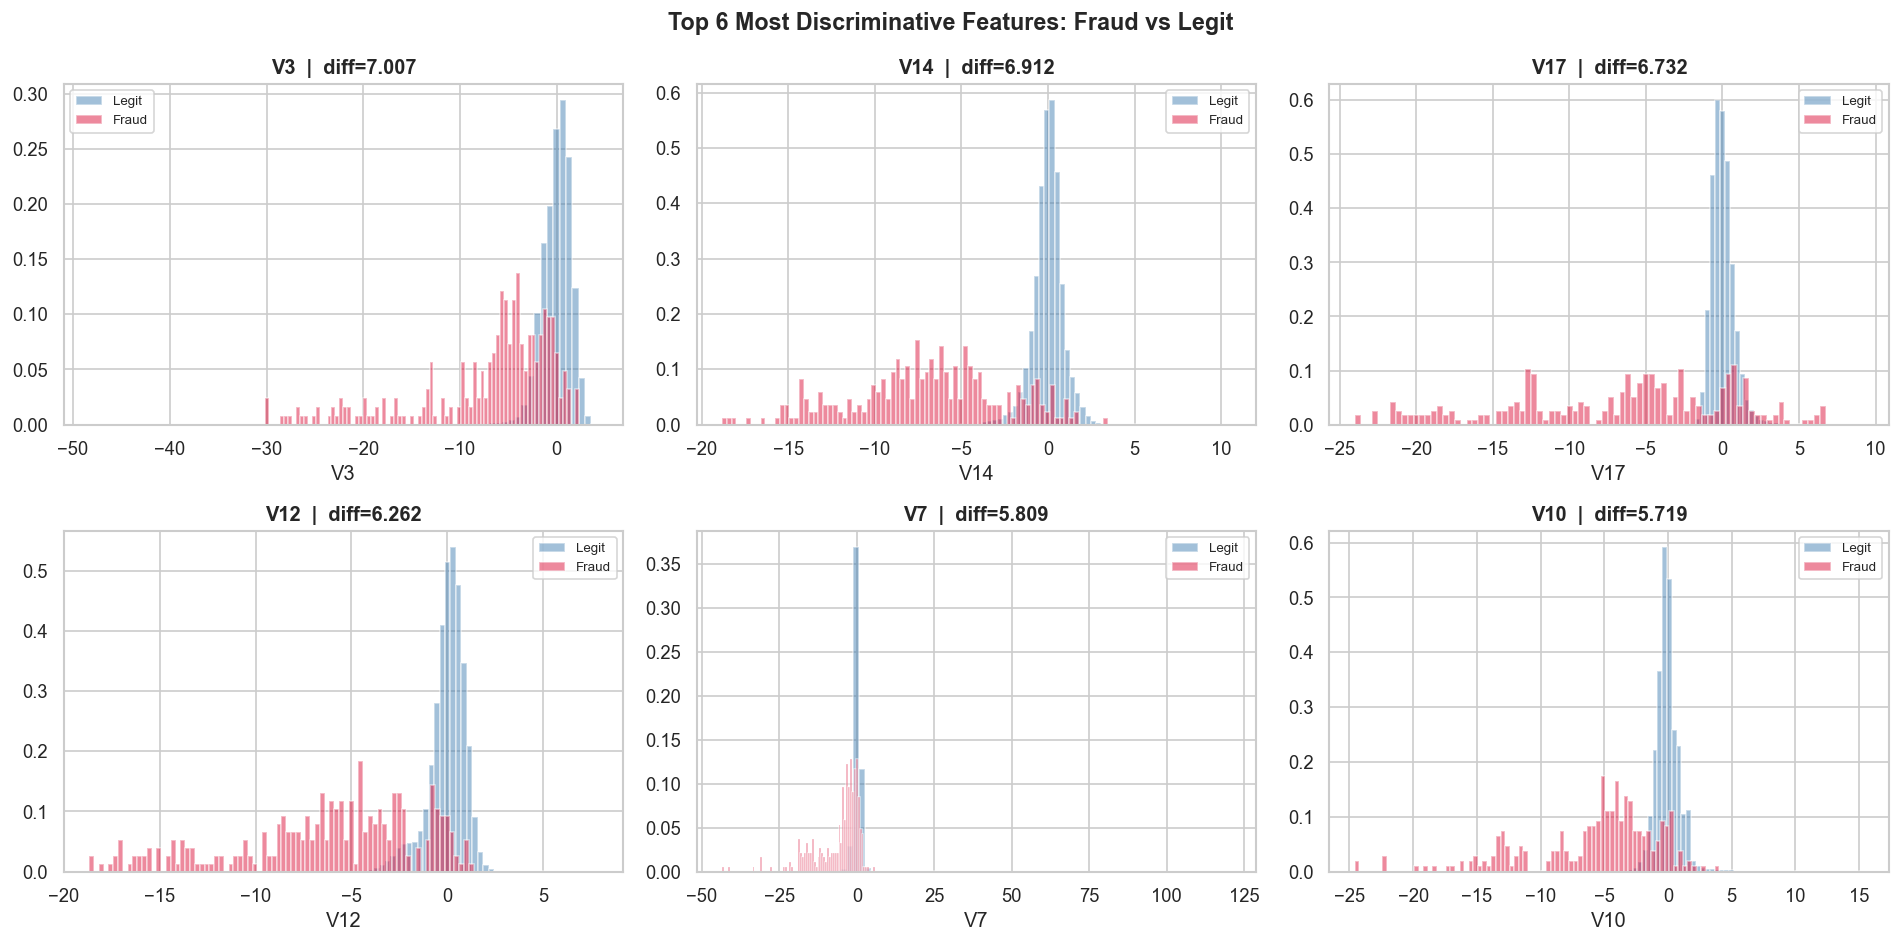

In [27]:
# ═══════════════════════════════════════════════════════════
# CELL 9 — Distributions of Top Features (Fraud vs Legit)
# ═══════════════════════════════════════════════════════════
top_features = mean_diff_series.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    ax.hist(legit_df[col], bins=80, alpha=0.5,
            color="steelblue", label="Legit",  density=True)
    ax.hist(fraud_df[col], bins=80, alpha=0.5,
            color="crimson",   label="Fraud",  density=True)
    ax.set_title(f"{col}  |  diff={mean_diff[col]:.3f}", fontweight="bold")
    ax.legend(fontsize=8)
    ax.set_xlabel(col)

plt.suptitle("Top 6 Most Discriminative Features: Fraud vs Legit",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/top_features_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

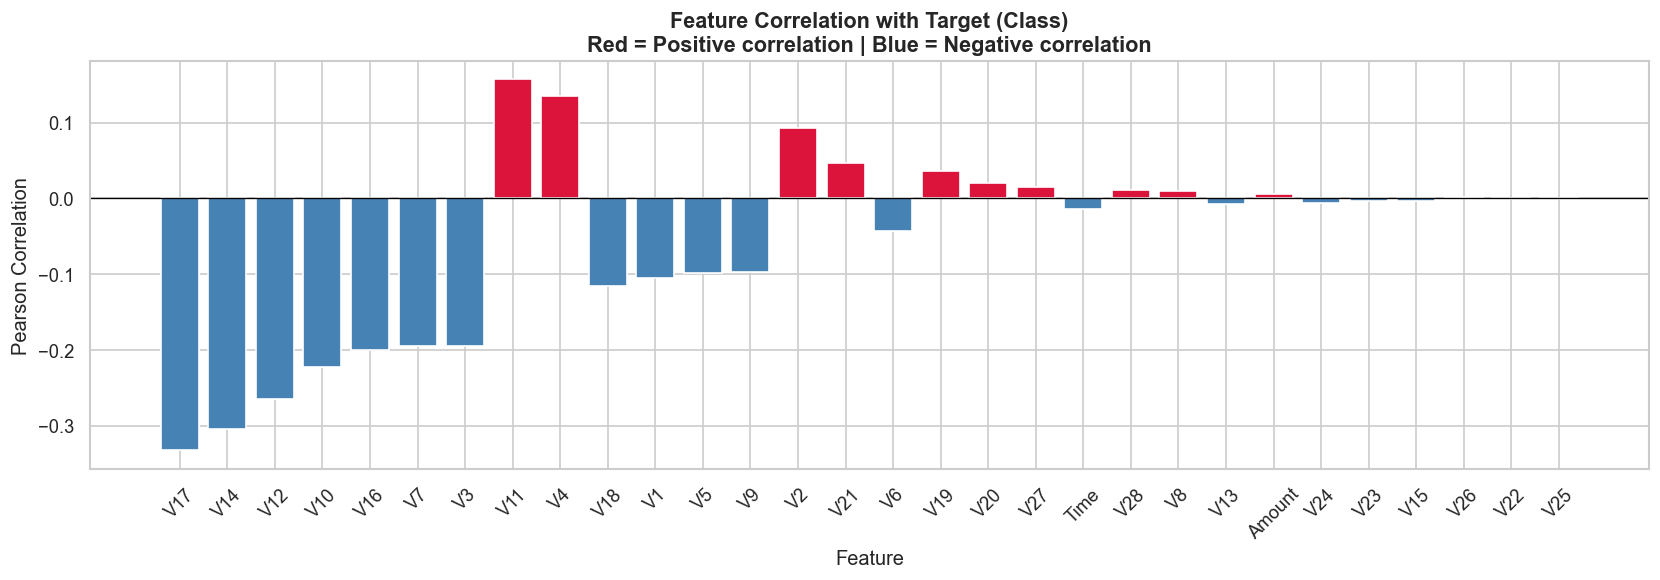

── Top 10 Correlated Features with Target ───
V17   -0.3327
V14   -0.3046
V12   -0.2648
V10   -0.2223
V16   -0.2005
V7    -0.1946
V3    -0.1943
V11    0.1572
V4     0.1348
V18   -0.1157
Name: Class, dtype: float64


In [28]:
# ═══════════════════════════════════════════════════════════
# CELL 10 — Correlation with Target
# ═══════════════════════════════════════════════════════════

# Correlation of each feature with Class
target_corr = train_df.corr()["Class"].drop("Class").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))

colors = ["crimson" if v > 0 else "steelblue" for v in target_corr.values]
ax.bar(target_corr.index, target_corr.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Target (Class)\n"
             "Red = Positive correlation | Blue = Negative correlation",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Pearson Correlation")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_with_target.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("── Top 10 Correlated Features with Target ───")
print(target_corr.head(10).round(4))

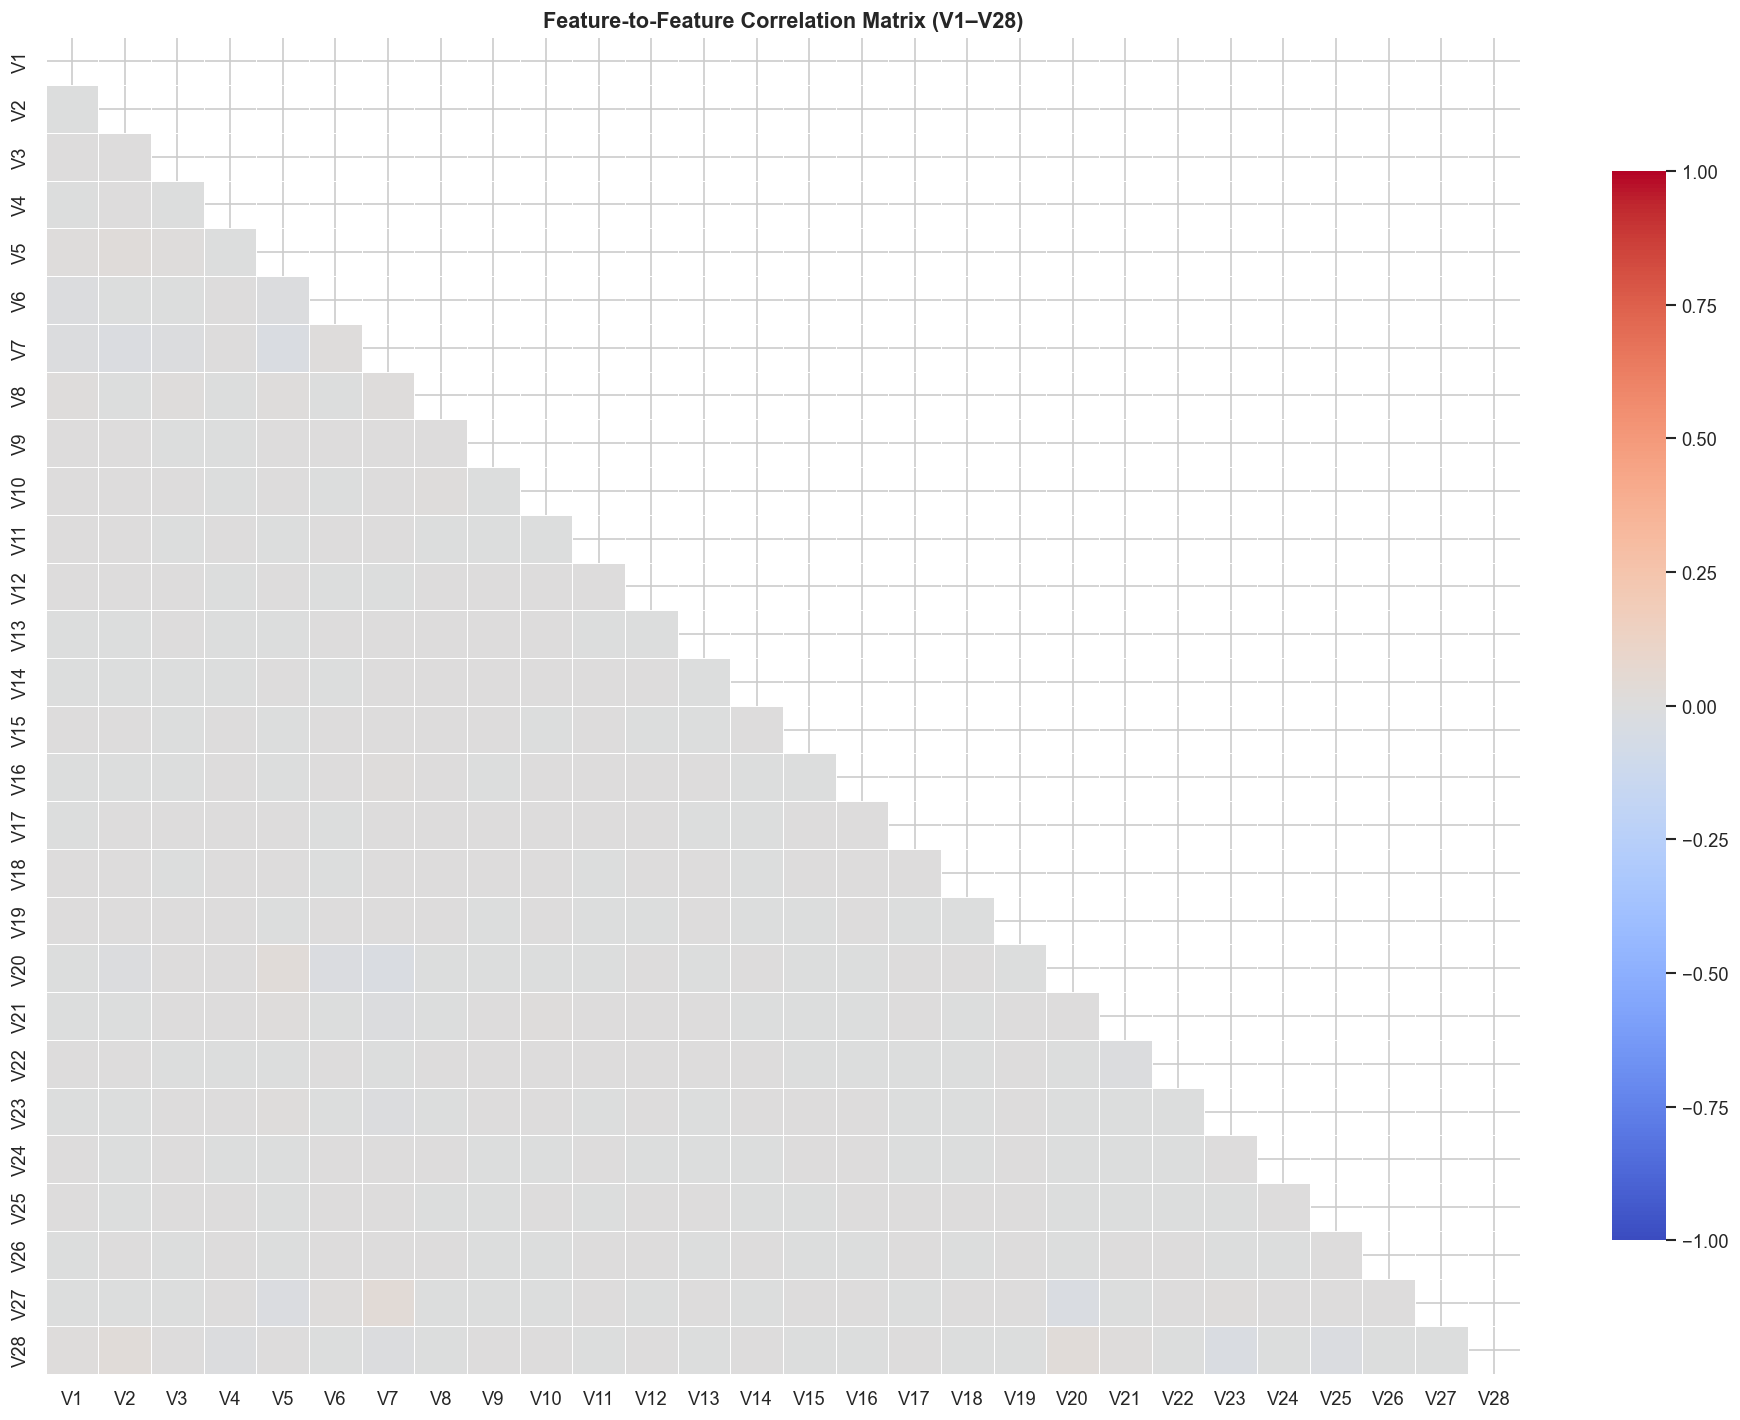

── Highly Correlated Feature Pairs (|corr| > 0.5) ───
  ✅ No highly correlated feature pairs found


In [29]:
# ═══════════════════════════════════════════════════════════
# CELL 11 — Feature-to-Feature Correlation Heatmap
# ═══════════════════════════════════════════════════════════

v_features = [f"V{i}" for i in range(1, 29)]

corr_matrix = train_df[v_features].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    ax=ax,
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Feature-to-Feature Correlation Matrix (V1–V28)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Print highly correlated pairs (|corr| > 0.5)
print("── Highly Correlated Feature Pairs (|corr| > 0.5) ───")
high_corr = []
for i in range(len(v_features)):
    for j in range(i+1, len(v_features)):
        val = abs(corr_matrix.iloc[i, j])
        if val > 0.5:
            high_corr.append((v_features[i], v_features[j], round(val, 3)))

if high_corr:
    for f1, f2, c in sorted(high_corr, key=lambda x: -x[2]):
        print(f"  {f1} — {f2} : {c}")
else:
    print("  ✅ No highly correlated feature pairs found")

In [30]:
# ═══════════════════════════════════════════════════════════
# CELL 12 — Amount & Time Correlation
# ═══════════════════════════════════════════════════════════

print("── Correlation of Amount and Time with Target ───")
print(f"  Amount : {train_df['Amount'].corr(train_df['Class']):.4f}")
print(f"  Time   : {train_df['Time'].corr(train_df['Class']):.4f}")

# log_amount vs target
train_df["log_amount"] = np.log1p(train_df["Amount"])
train_df["hour_of_day"] = (train_df["Time"] // 3600) % 24

print(f"\n── After Feature Engineering ───────────────")
print(f"  log_amount  : {train_df['log_amount'].corr(train_df['Class']):.4f}")
print(f"  hour_of_day : {train_df['hour_of_day'].corr(train_df['Class']):.4f}")

# Drop temp columns
train_df.drop(columns=["log_amount", "hour_of_day"], inplace=True)

── Correlation of Amount and Time with Target ───
  Amount : 0.0063
  Time   : -0.0144

── After Feature Engineering ───────────────
  log_amount  : -0.0069
  hour_of_day : -0.0174


In [31]:
# ═══════════════════════════════════════════════════════════
# CELL 13 — EDA Summary & Decisions
# ═══════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════╗
║              EDA FINDINGS & DECISIONS                        ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DATASET FACTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ✅ Total train samples   : 170,884
 ✅ Fraud samples         : 305  (0.178%)
 ✅ Legitimate samples    : 170,579
 ✅ Imbalance ratio       : 559:1
 ✅ Missing values        : None
 ✅ Feature types         : All numerical

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. EXTREME IMBALANCE (559:1)
    → Standard accuracy is meaningless
    → Need: Sampling + scale_pos_weight + Threshold Tuning

 2. AMOUNT IS SKEWED
    → Raw Amount: max = 25,691  vs  median = 22
    → log1p transform will reduce skewness
    → After log: better distribution for models

 3. TIME HAS PATTERNS
    → Fraud spikes at specific hours (2am, 11am, 5pm)
    → hour_of_day captures this pattern better than raw seconds

 4. V FEATURES ARE INDEPENDENT (PCA)
    → No highly correlated pairs found (all < 0.5)
    → No need to drop any feature due to multicollinearity

 5. MOST DISCRIMINATIVE FEATURES
    → Top negative: V17, V14, V12, V10, V16, V7, V3
    → Top positive: V11, V4
    → Weak features: V22, V25, V26 (near zero correlation)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 FEATURE ENGINEERING DECISIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ✅ ADD    log_amount  = log1p(Amount)   → fix skewness
 ✅ ADD    hour_of_day = (Time//3600)%24 → capture time pattern
 ✅ DROP   Amount      → replaced by log_amount
 ✅ DROP   Time        → replaced by hour_of_day
 ✅ KEEP   V1 - V28    → all independent, no multicollinearity

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 MODELING DECISIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ✅ Sampling             → SMOTE, ADASYN, SMOTETomek...
 ✅ scale_pos_weight     → 559.28 in XGBoost
 ✅ Threshold Tuning     → via Precision-Recall Curve
 ✅ Scoring metric       → average_precision (not accuracy)
 ✅ CV Strategy          → StratifiedKFold (5 folds)
 ✅ Feature Selection    → SelectFromModel after sampling
 ✅ Calibration          → Isotonic / Platt Scaling
""")


╔══════════════════════════════════════════════════════════════╗
║              EDA FINDINGS & DECISIONS                        ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DATASET FACTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ✅ Total train samples   : 170,884
 ✅ Fraud samples         : 305  (0.178%)
 ✅ Legitimate samples    : 170,579
 ✅ Imbalance ratio       : 559:1
 ✅ Missing values        : None
 ✅ Feature types         : All numerical

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. EXTREME IMBALANCE (559:1)
    → Standard accuracy is meaningless
    → Need: Sampling + scale_pos_weight + Threshold Tuning

 2. AMOUNT IS SKEWED
    → Raw Amount: max = 25,691  vs  median = 22
    → log1p transform will reduce skewness
    → After log: better distribution for models

 3. TIME HAS PATTERNS
    → Fraud spikes at specific hours (2am, 1

In [32]:
# ═══════════════════════════════════════════════════════════
# CELL 14 — Save Final Feature List
# ═══════════════════════════════════════════════════════════

v_features   = [f"V{i}" for i in range(1, 29)]
final_features = v_features + ["log_amount", "hour_of_day"]

print(f"  Total features after engineering : {len(final_features)}")
print(f"  Features: {final_features}")

  Total features after engineering : 30
  Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'log_amount', 'hour_of_day']
